## Background

Date: 7/23/2026  
Goal: Download ET timeseries data for eddy station locations  
  
Background: Based on this tutorial: https://github.com/nasa/gesdisc-tutorials/blob/main/notebooks/How_to_Access_GiC_Time_Series_Service.ipynb.  
 
Note that data are returned in UTC; here I convert to mountain standard time

Initial Set Up
- Register for an [Earthdata](https://urs.earthdata.nasa.gov/) account
- Log in to account and generate a token
- Copy token as parameter into script below
- If call_nldas_time_series throws an error, you may need to turn on some apps under the  
Authorized Apps in your Earthdata account. I experimented with turning on the following  
but in the end did not need any of them:
  - Giovanni
  - NASA GESDISC DATA ARCHIVE	 
  - Hyrax in the cloud	 
  - New Harmony Giovanni Adapter

## Parameters

Copy your token from Earthdata into the parameters below

In [19]:
# token from EArthdata
token = "PASTE YOUR TOKEN HERE"
#name of data layer that we want
data = 'NLDAS_NOAH0125_H_2_0_Evap'
# offset from UTC
utc_offset = -7

In [ ]:
# station parameters
# note that the time start and end should be in UTC
lat = 37.7359692085905
lon = -111.55517578125
time_start =  '2025-06-01'
time_end = '2025-06-30'

## Import Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
import sys
sys.path.append('nldas_read_functions')
from nldas_read_functions import call_nldas_time_series, parse_nldas_csv

## Call Service and Parse Output

In [14]:
# format the datetime
time_start = pd.to_datetime(time_start)
time_start = time_start.strftime("%Y-%m-%dT%H:%M:%S")
time_end = pd.to_datetime(time_end)
time_end = time_end.strftime("%Y-%m-%dT%H:%M:%S")

In [15]:
# send api request
ts = call_nldas_time_series(lat,lon,time_start,time_end,data, token)

Status Code: 200


In [16]:
# parse response
headers,df = parse_nldas_csv(ts)
df['timestamp_local'] = df['Timestamp'] + pd.Timedelta(hours=utc_offset)
print(df.head())

            Timestamp  Total evapotranspiration     timestamp_local
0 2025-06-01 00:00:00                    0.0316 2025-05-31 17:00:00
1 2025-06-01 01:00:00                    0.0227 2025-05-31 18:00:00
2 2025-06-01 02:00:00                    0.0131 2025-05-31 19:00:00
3 2025-06-01 03:00:00                    0.0010 2025-05-31 20:00:00
4 2025-06-01 04:00:00                    0.0007 2025-05-31 21:00:00


Text(0.5, 1.0, 'NLDAS_NOAH0125_H_2_0_Evap at [37.6875,-111.5625]')

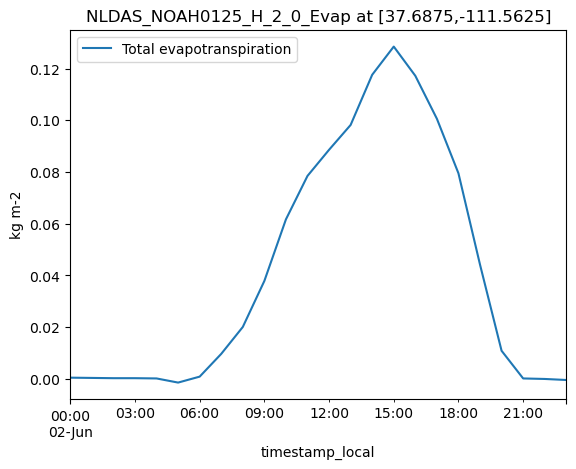

In [18]:
# plot a single day- make sure time alignment is correct
df_sub = df[df.timestamp_local.dt.floor('D') == pd.to_datetime('2025-06-02')]

ax = plt.gca()
df_sub.plot(x="timestamp_local",y=headers["param_name"],ax=ax)
ax.set_ylabel(headers["unit"])
ax.set_title("{} at [{},{}]".format(data,headers["lat"],headers["lon"]))